<a href="https://colab.research.google.com/github/emillyllemke/Fundamentos_Inteligencia_Artificial/blob/main/Atividade_UBS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Dados com base em informações do SUS

In [6]:
#Importar bibliotecas
import pandas as pd #manipulação de dados
import matplotlib.pyplot as plt #visualização gráfica
import seaborn as sns #visualização gráfica

In [7]:
#Carregamento da base de dados
df = pd.read_csv('/content/Unidades_Basicas_Saude-UBS.csv', sep=';')
df.head() #visualizar primeiras 5 linhas

,CNES,UF,IBGE,NOME,LOGRADOURO,BAIRRO,LATITUDE,LONGITUDE
0,23914,31,310620,CENTRO DE SAUDE JARDIM MONTANHES,RUA SAUDE,PADRE EUSTAQUIO,-19.911503,"-43,9914089036"
1,106143,26,261000,UBS FRANCISCO VIEIRA DE MELO,QUADRA 50,QUILOMBO II,-8.705590,"-35,5995386839"
2,302,26,260290,USF SANTO ESTEVAO,RUA DO CEMITERIO,PONTE DOS CARVALHOS,-8.218112,"-35,2294359"
3,405132,26,261350,UNIDADE DE SAUDE SABINO LUCAS DE BARROS,TRAVESSA SAO PAULO,VILA DELMIRO,-7.866081,"-38,7650871277"
4,881007,26,261000,UBS MARIA ALICE,QUADRA 11,QUILOMBO 2,-8.698513,"-35,6040179729"


In [8]:
df.tail() #visualizar últimas 5 linhas

,CNES,UF,IBGE,NOME,LOGRADOURO,BAIRRO,LATITUDE,LONGITUDE
47668,9999078,31,310710,PRBE PRESIDIO DE BOA ESPERANCA,RUA MARIQUINHA GOMES,NOVA ERA,-21.090000,"-45,565"
47669,9999280,25,250070,EMAD II SAO JOAO DO RIO DO PEIXE,RUA LAURENIO FIRMEZA,CENTRO,-6.725174,"-38,4488010406"
47670,9999396,29,291072,UNIDADE BASICA DE SAUDE IRIS LOPES,RUA FABIA SPINDOLA,ROCA DO POVO,-16.312479,"-39,5957565308"
47671,9999493,41,410765,UNIDADE DE SAUDE SANTAREM,RUA NIGER,NACOES,-25.671526,"-49,2914700508"
47672,9999949,35,352900,USF JARDIM MARACA,RUA JOSEFA PEREIRA ALVES,JARDIM MACARA,-22.161369,"-50,0109016"


In [9]:
#Visualização do tipo de dados (data types)
df.dtypes

,0
CNES,int64
UF,int64
IBGE,int64
NOME,object
LOGRADOURO,object
BAIRRO,object
LATITUDE,float64
LONGITUDE,object


### Distribuição de UBS por Estado (IBGE)


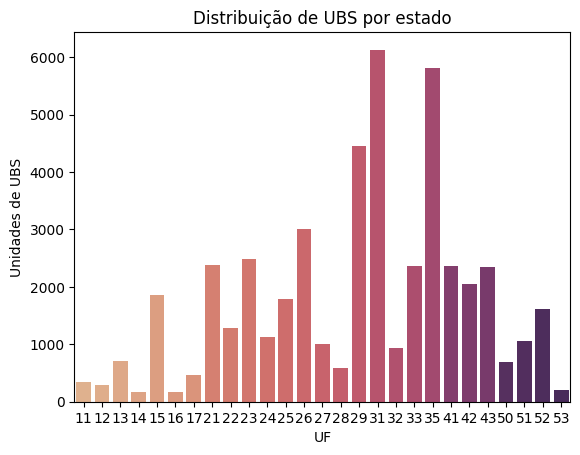

In [11]:
#Distribuição de UBS por estado
sns.countplot(x='UF', data=df, palette='flare', hue='UF', legend=False)
plt.title('Distribuição de UBS por estado')
plt.xlabel('UF')
plt.ylabel('Unidades de UBS')
plt.show()

###Distribuição de bairros por estado com maior número de UBS


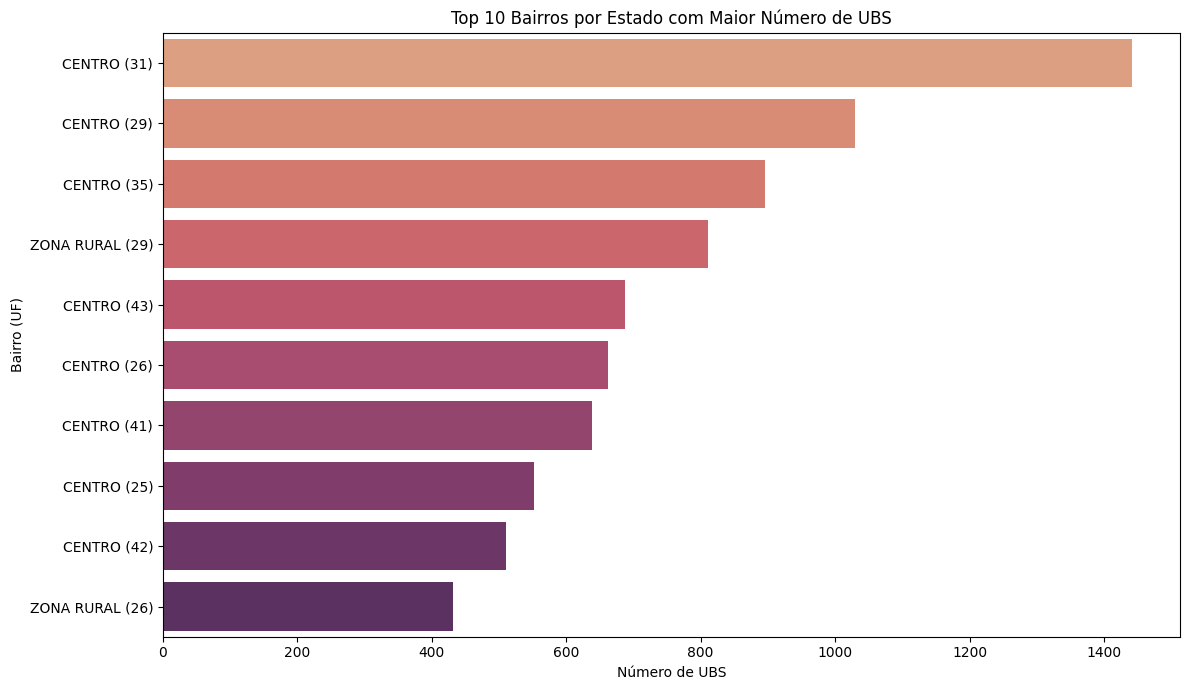

In [12]:
#Ordenar os resultados para pegar os top 10
ubs_por_bairro_estado = df.groupby(['BAIRRO', 'UF']).size().reset_index(name='COUNT_UBS')
top_ubs_por_bairro_estado = ubs_por_bairro_estado.sort_values(by='COUNT_UBS', ascending=False).head(10)

#Distribuição de bairros por estado com maior número de UBS
plt.figure(figsize=(12, 7))
sns.barplot(x='COUNT_UBS', y=top_ubs_por_bairro_estado['BAIRRO'] + ' (' + top_ubs_por_bairro_estado['UF'].astype(str) + ')', data=top_ubs_por_bairro_estado, palette='flare', hue=top_ubs_por_bairro_estado['BAIRRO'] + ' (' + top_ubs_por_bairro_estado['UF'].astype(str) + ')', legend=False)
plt.title('Top 10 Bairros por Estado com Maior Número de UBS')
plt.xlabel('Número de UBS')
plt.ylabel('Bairro (UF)')
plt.tight_layout()
plt.show()

###Distribuição Espacial das UBS no Brasil

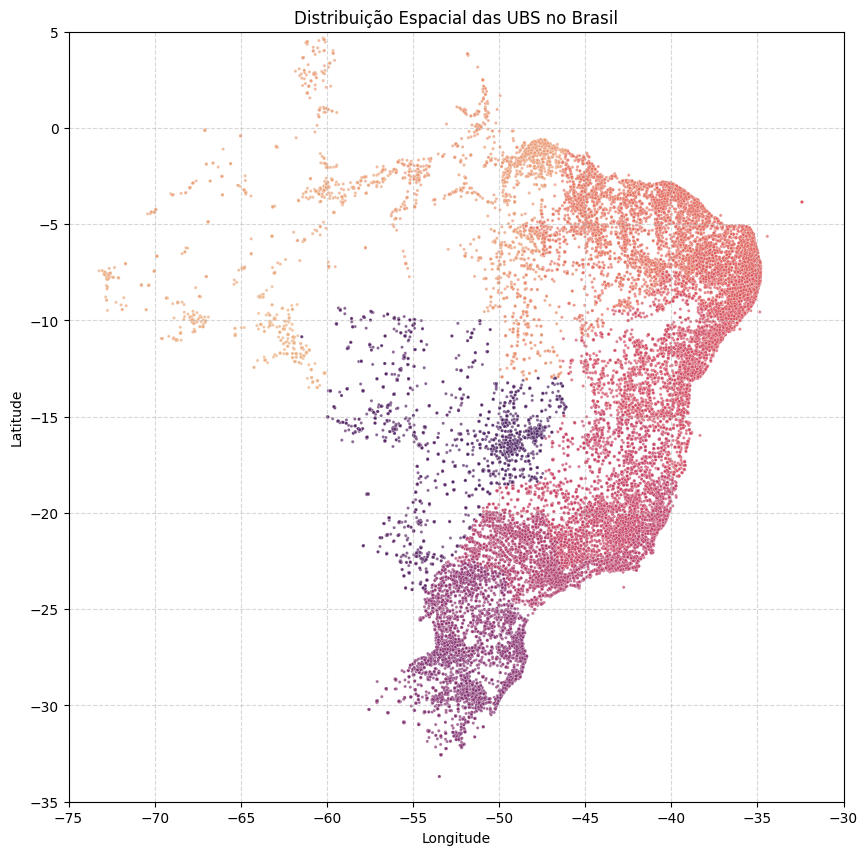

In [20]:
df['LONGITUDE'] = df['LONGITUDE'].astype(str).str.replace(',', '.')
df['LONGITUDE'] = pd.to_numeric(df['LONGITUDE'], errors='coerce')

# Distribuição espacial com Seaborn
plt.figure(figsize=(10, 10))

# Trocamos plt.scatter por sns.scatterplot
# hue='UF' distribui as cores com base no código do estado
sns.scatterplot(data=df, x='LONGITUDE', y='LATITUDE', hue='UF', palette='flare', s=5, alpha=0.7, legend=False)

plt.title('Distribuição Espacial das UBS no Brasil')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)

plt.xlim(-75, -30)
plt.ylim(-35, 5)
plt.show()

##Top 15 Bairros com mais UBS


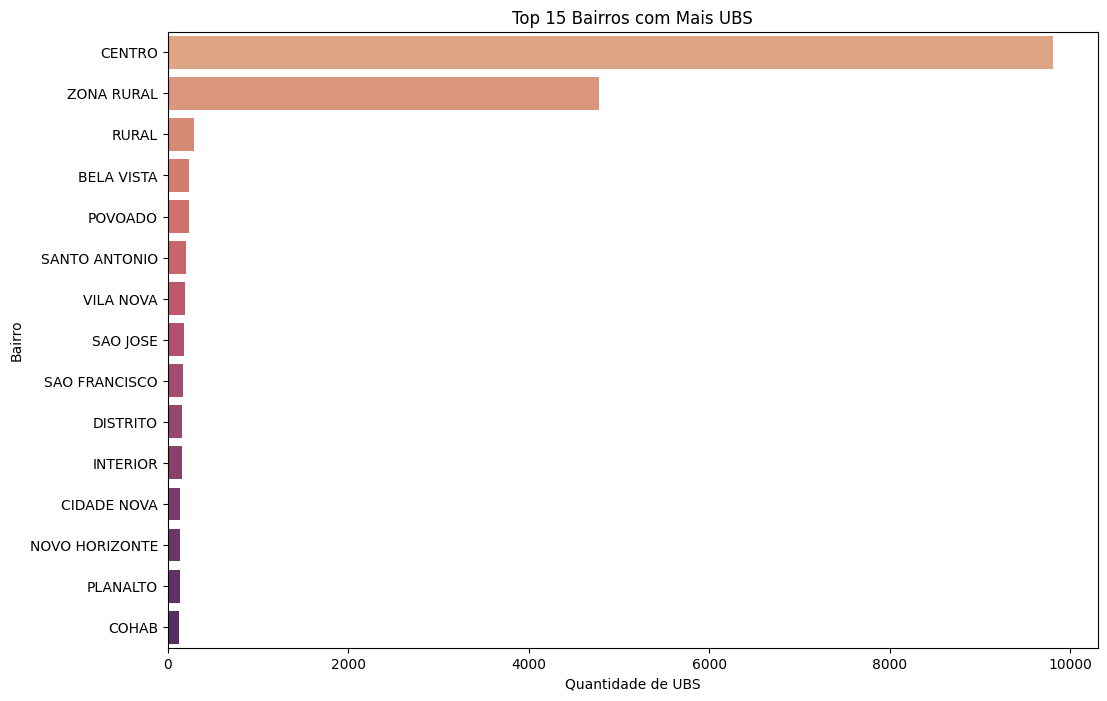

In [16]:
# Top 15 bairros com mais UBS
plt.figure(figsize=(12,8))

top_bairros = df['BAIRRO'].value_counts().head(15)

sns.barplot(x=top_bairros.values, y=top_bairros.index, palette='flare', hue=top_bairros.index, legend=False)

plt.title('Top 15 Bairros com Mais UBS')
plt.xlabel('Quantidade de UBS')
plt.ylabel('Bairro')
plt.show()

###UBS por Região do Brasil

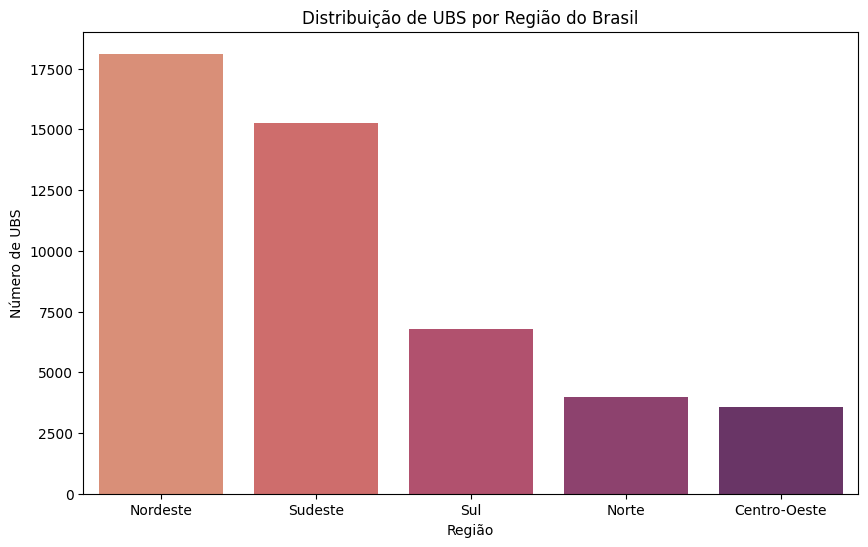

In [23]:
# Função para mapear o código UF (IBGE) para as regiões
def obter_regiao(uf):
    if uf in [11, 12, 13, 14, 15, 16, 17]: return 'Norte'
    if uf in [21, 22, 23, 24, 25, 26, 27, 28, 29]: return 'Nordeste'
    if uf in [31, 32, 33, 35]: return 'Sudeste'
    if uf in [41, 42, 43]: return 'Sul'
    if uf in [50, 51, 52, 53]: return 'Centro-Oeste'
    return 'Desconhecido'

# Criar uma nova coluna de Região
df['Região'] = df['UF'].apply(obter_regiao)

# Contar por região
regioes_counts = df['Região'].value_counts().reset_index()
regioes_counts.columns = ['Região', 'Contagem']

plt.figure(figsize=(10, 6))
sns.barplot(data=regioes_counts, x='Região', y='Contagem', hue='Região', palette='flare', legend=False)
plt.title('Distribuição de UBS por Região do Brasil')
plt.xlabel('Região')
plt.ylabel('Número de UBS')
plt.show()